# Experiment 3: Decision Tree Classifier

**Course:** 23CSE301 — Machine Learning Lab  
**Topic:** Decision Tree for Binary Classification  
**Dataset:** `diabetes.csv (Pima Indians Diabetes)`  
**Lab Book Reference:** §7 Decision Tree Classifier, page 26–30

---

## 🎯 Objective

Implement a **Decision Tree Classifier** on the Pima Indians Diabetes dataset. We use **entropy / information gain** as the splitting criterion (matching the Lab Activity Book), compare against Gini impurity, visualise the resulting tree, and inspect feature importance.

## ▶️ How to Run This Notebook

> **Option A — Google Colab (recommended if you don't have Python locally):**
> 1. Upload the entire `ML-Lab-Activities-Complete` folder to your Google Drive
>    (so it appears at `My Drive/ML-Lab-Activities-Complete/`).
> 2. In Colab, `File → Open notebook → Google Drive → 03-Decision-Tree-Classifier/03_*.ipynb`.
> 3. The first code cell auto-mounts Drive, chdir's to this experiment folder,
>    and creates an `outputs/` subfolder for every figure.
>
> **Option B — Local Jupyter:**
> ```bash
> # 1. (optional) create a virtual-env
> python -m venv .venv && source .venv/bin/activate
>
> # 2. install dependencies (one-time)
> pip install -r requirements.txt
>
> # 3. launch Jupyter from the repository root
> jupyter notebook 03-Decision-Tree-Classifier/03_*.ipynb
> ```
>
> **Option C — Headless execution:**
> ```bash
> jupyter nbconvert --to notebook --execute \
>   03-Decision-Tree-Classifier/03_*.ipynb \
>   --output executed.ipynb
> ```

Datasets are read from `../datasets/` (relative to the notebook's folder).
Generated figures are **auto-saved** to `./outputs/` inside this experiment's folder.


In [1]:
# === Environment setup (works in both Google Colab and local Jupyter) ===
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # Adjust this path if you placed the folder elsewhere in your Drive
    BASE = '/content/drive/MyDrive/ML-Lab-Activities-Complete'
    os.chdir(os.path.join(BASE, '03-Decision-Tree-Classifier'))
    print(f'Running in Google Colab. Changed CWD to: {os.getcwd()}')
else:
    print(f'Running locally. CWD: {os.getcwd()}')

# Create outputs/ folder in this experiment's directory
OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Auto-save every matplotlib figure to outputs/ ---
# We patch plt.show() so that BEFORE a figure is shown, it is also saved
# to the outputs/ folder.  In the Jupyter inline backend, plt.show() is
# essentially a no-op (display happens automatically at cell-end), but it
# is still called inside every plotting cell — so this is the right hook.
import matplotlib.pyplot as plt

_fig_counter = [0]
_orig_plt_show = plt.show
def _save_and_show(*args, **kwargs):
    # Save every currently-open figure before showing
    for fnum in plt.get_fignums():
        _fig_counter[0] += 1
        fig = plt.figure(fnum)
        fname = f'figure_{_fig_counter[0]:03d}.png'
        try:
            fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=120, bbox_inches='tight')
        except Exception as e:
            print(f'Warning: could not save {fname}: {e}')
    _orig_plt_show(*args, **kwargs)
plt.show = _save_and_show

print('✅ Setup complete.')
print(f'   Datasets will be read from: {os.path.join(os.getcwd(), "..", "datasets")}')
print(f'   Figures will be auto-saved to: {OUTPUT_DIR}')


Running locally. CWD: /home/z/my-project/work/final/03-Decision-Tree-Classifier


✅ Setup complete.
   Datasets will be read from: /home/z/my-project/work/final/03-Decision-Tree-Classifier/../datasets
   Figures will be auto-saved to: /home/z/my-project/work/final/03-Decision-Tree-Classifier/outputs


## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import metrics
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             classification_report, precision_score,
                             recall_score, f1_score)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
import warnings; warnings.filterwarnings('ignore')
print("Libraries imported.")


Libraries imported.


## 2. Load & Explore Dataset

In [3]:
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin',
             'bmi', 'pedigree', 'age', 'label']

data = pd.read_csv('../datasets/diabetes.csv', header=None, names=col_names)

print(f"Shape: {data.shape}")
display(data.head())


Shape: (768, 9)


,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,6,129,71,15,202,38.8,0.119,55,1
1,14,113,70,29,3,17.3,0.330,29,0
2,10,144,75,11,27,40.1,0.142,55,0
3,7,53,84,17,18,41.7,0.080,31,1
4,6,127,81,20,21,29.9,0.491,64,1


## 3. Check for Null Values

In [4]:
print("Null values per column:")
print(data.isnull().sum())
print("\n✅ No missing values." if data.isnull().sum().sum() == 0 else "⚠ Handle missing values.")


Null values per column:
pregnant    0
glucose     0
bp          0
skin        0
insulin     0
bmi         0
pedigree    0
age         0
label       0
dtype: int64

✅ No missing values.


## 4. Define Features and Target

In [5]:
feature_cols = ['pregnant', 'glucose', 'bp', 'skin', 'insulin',
               'bmi', 'pedigree', 'age']

X = data[feature_cols]
y = data['label']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (768, 8)
y shape: (768,)


## 5. Split Data into Training and Testing Sets

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=5
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (614, 8), Test: (154, 8)


## 6. Train Decision Tree (criterion = 'entropy')

The lab book uses `criterion='entropy'` (information gain). We match it exactly.


In [7]:
model = DecisionTreeClassifier(criterion='entropy', random_state=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"First 20 predictions: {y_pred[:20]}")
print(f"First 20 actual     : {y_test.values[:20]}")


First 20 predictions: [0 0 0 1 1 1 0 0 0 0 1 0 0 0 0 1 1 1 0 0]
First 20 actual     : [0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 1 0 0 0 0]


## 7. Evaluation Metrics

In [8]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print(f"\nAccuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


Confusion Matrix:
[[66 38]
 [29 21]]

Accuracy  : 0.5649  (56.49%)
Precision : 0.3559
Recall    : 0.4200
F1 Score  : 0.3853


## 8. Visualise the Confusion Matrix

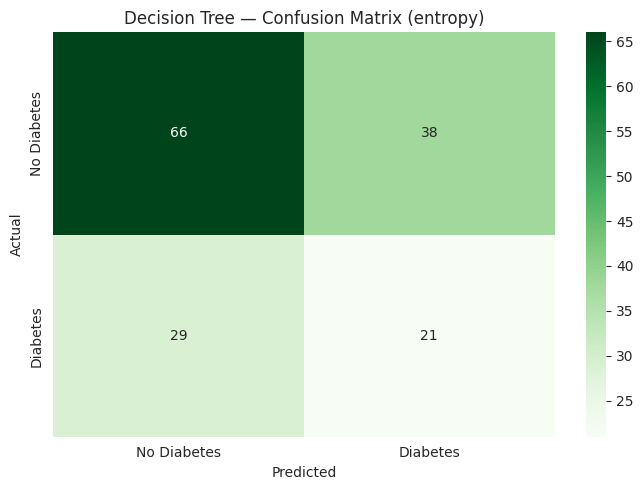

In [9]:
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree — Confusion Matrix (entropy)')
plt.tight_layout()
plt.show()


## 9. Visualise the Decision Tree

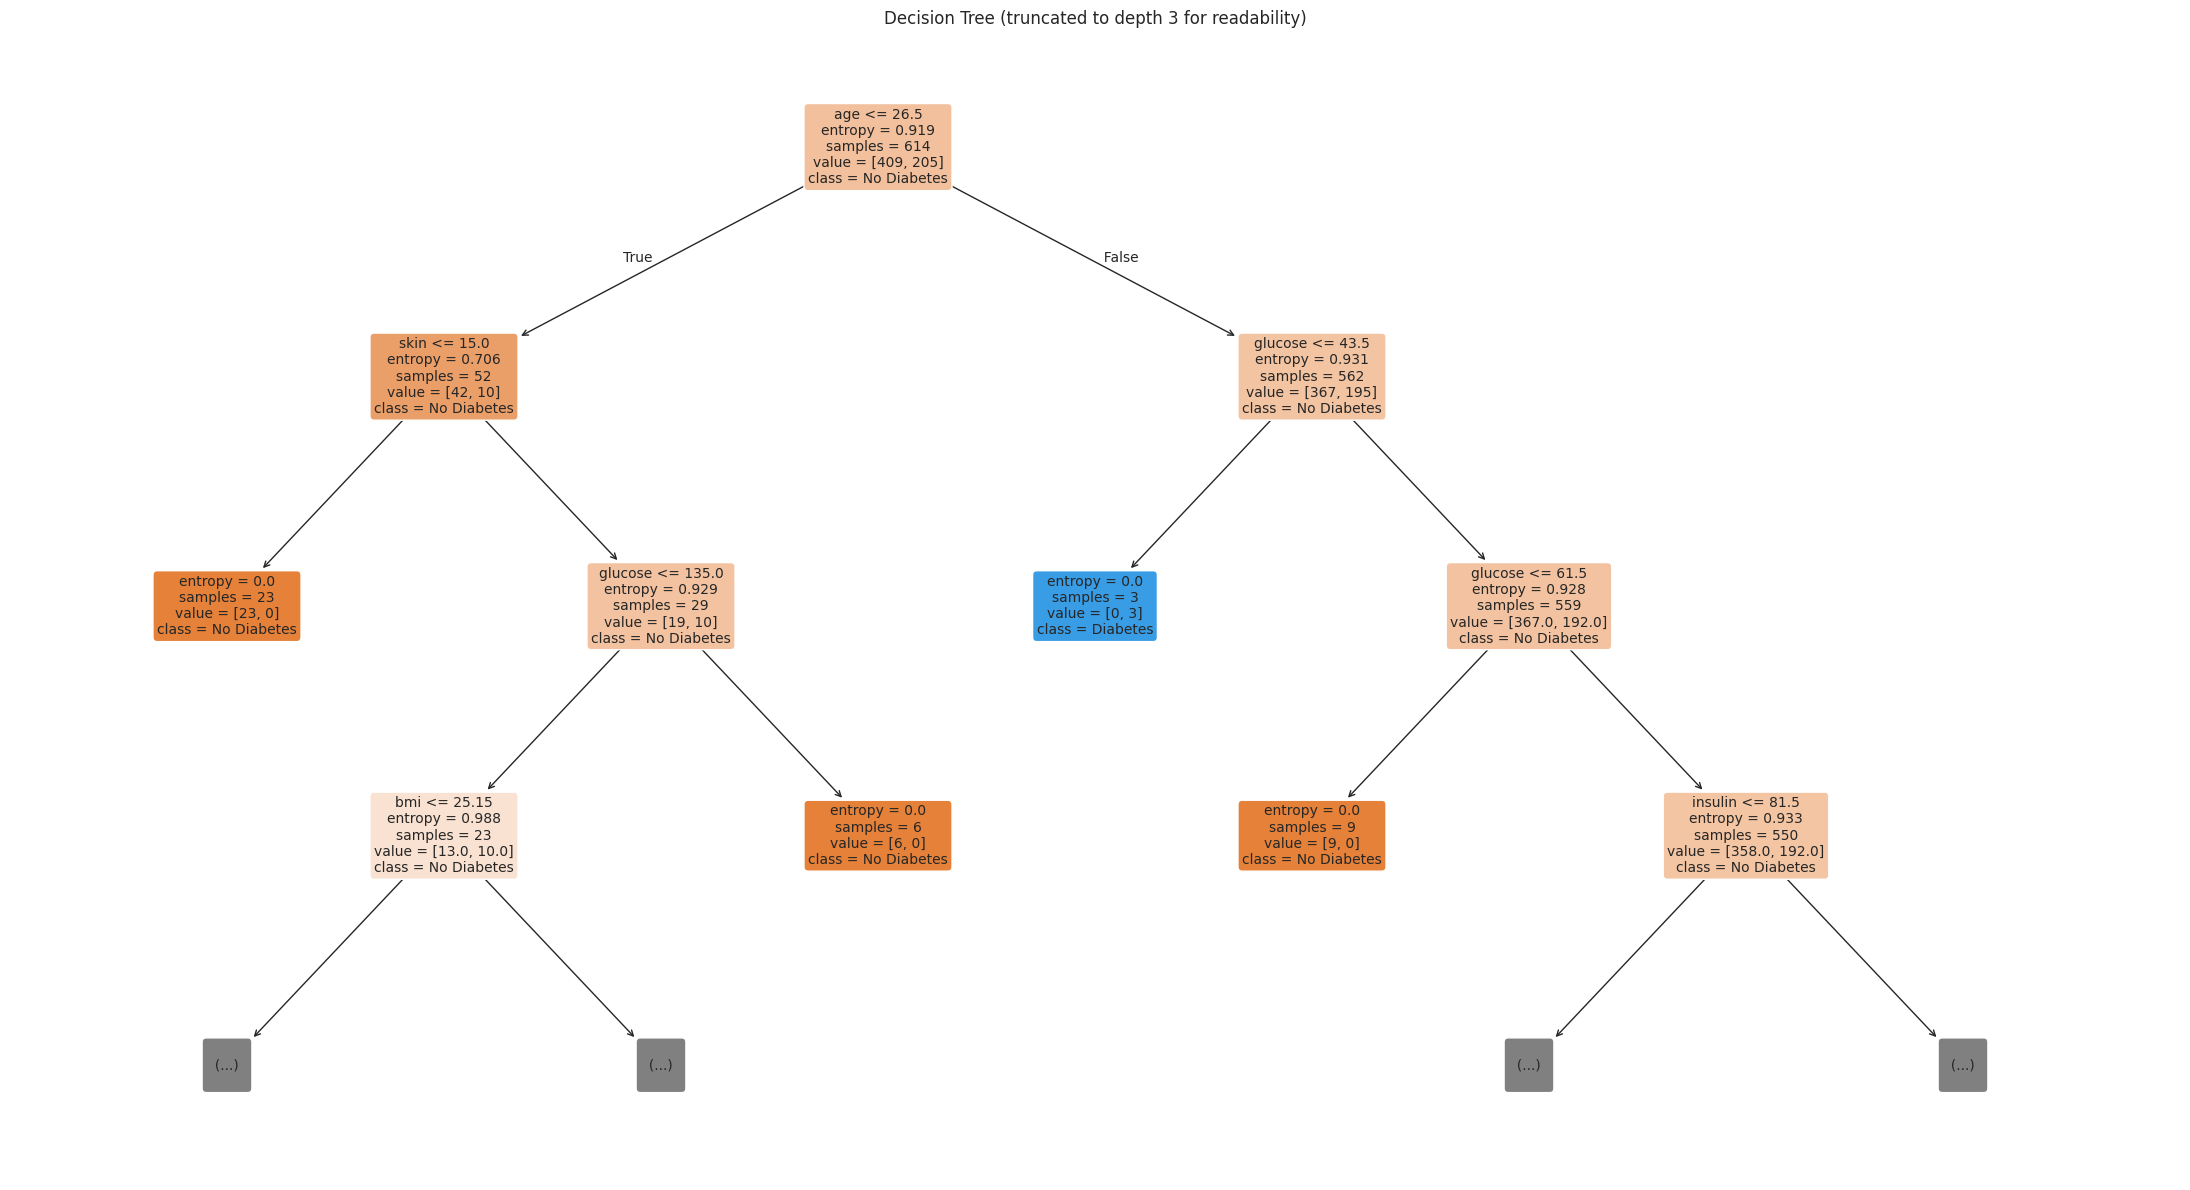

Tree depth     : 21
Leaves         : 141


In [10]:
plt.figure(figsize=(22, 12))
plot_tree(model,
          feature_names=feature_cols,
          class_names=['No Diabetes', 'Diabetes'],
          filled=True, rounded=True,
          fontsize=10, max_depth=3)
plt.title('Decision Tree (truncated to depth 3 for readability)')
plt.tight_layout()
plt.show()

print(f"Tree depth     : {model.get_depth()}")
print(f"Leaves         : {model.get_n_leaves()}")


## 10. Feature Importance

,Feature,Importance
5,bmi,0.169918
2,bp,0.133897
4,insulin,0.130824
6,pedigree,0.130307
1,glucose,0.125995
7,age,0.118123
3,skin,0.106023
0,pregnant,0.084912


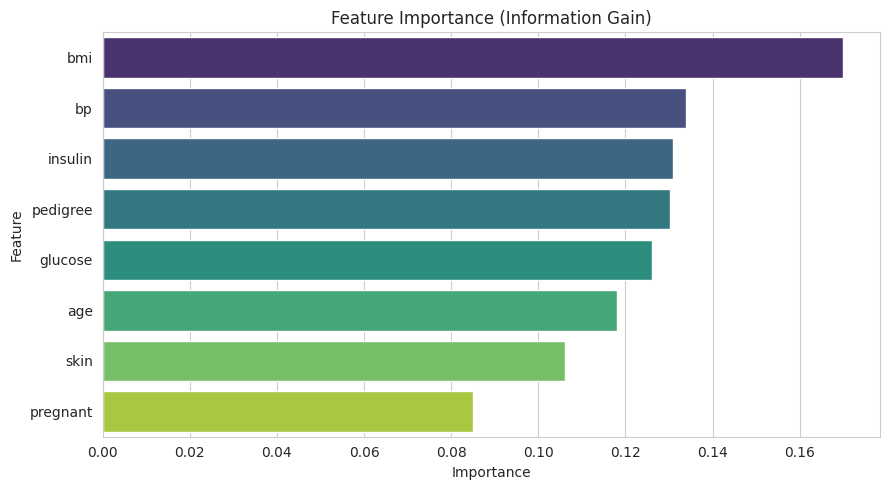

In [11]:
importance = pd.DataFrame({
    'Feature'    : feature_cols,
    'Importance' : model.feature_importances_,
}).sort_values('Importance', ascending=False)
display(importance)

plt.figure(figsize=(9, 5))
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title('Feature Importance (Information Gain)')
plt.tight_layout()
plt.show()


## 11. Classification Report

In [12]:
print(classification_report(y_test, y_pred,
      target_names=['No Diabetes', 'Diabetes']))


              precision    recall  f1-score   support

 No Diabetes       0.69      0.63      0.66       104
    Diabetes       0.36      0.42      0.39        50

    accuracy                           0.56       154
   macro avg       0.53      0.53      0.52       154
weighted avg       0.58      0.56      0.57       154



## 12. Compare: Entropy vs Gini

Both splitting criteria usually give similar trees, but on some datasets one may slightly
outperform the other.


In [13]:
model_gini = DecisionTreeClassifier(criterion='gini', random_state=5)
model_gini.fit(X_train, y_train)
y_pred_gini = model_gini.predict(X_test)

comparison = pd.DataFrame({
    'Criterion' : ['Entropy', 'Gini'],
    'Accuracy'  : [accuracy_score(y_test, y_pred),
                   accuracy_score(y_test, y_pred_gini)],
    'Precision' : [precision_score(y_test, y_pred),
                   precision_score(y_test, y_pred_gini)],
    'Recall'    : [recall_score(y_test, y_pred),
                   recall_score(y_test, y_pred_gini)],
    'F1'        : [f1_score(y_test, y_pred),
                   f1_score(y_test, y_pred_gini)],
    'Depth'     : [model.get_depth(), model_gini.get_depth()],
}).round(4)
print(comparison.to_string(index=False))


Criterion  Accuracy  Precision  Recall     F1  Depth
  Entropy    0.5649     0.3559    0.42 0.3853     21
     Gini    0.5390     0.3220    0.38 0.3486     19


## 13. Limit Depth to Avoid Overfitting

A fully grown tree (depth = 11 above) memorises the training data. Limiting `max_depth`
typically improves generalisation.


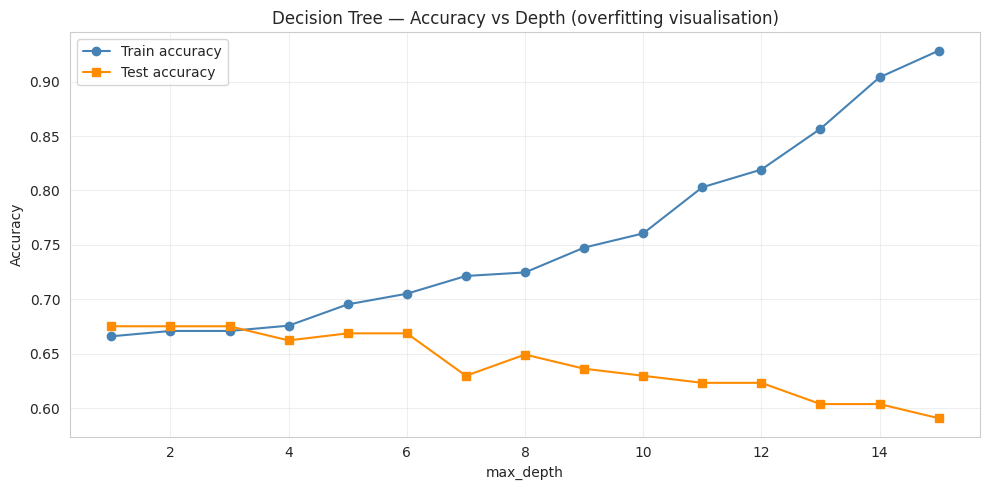

In [14]:
train_acc, test_acc = [], []
depths = range(1, 16)
for d in depths:
    t = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=5)
    t.fit(X_train, y_train)
    train_acc.append(t.score(X_train, y_train))
    test_acc.append(t.score(X_test,  y_test))

plt.figure(figsize=(10, 5))
plt.plot(depths, train_acc, 'o-', label='Train accuracy', color='steelblue')
plt.plot(depths, test_acc,  's-', label='Test accuracy',  color='darkorange')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree — Accuracy vs Depth (overfitting visualisation)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 📝 Exercises

> Submit the Colab link or GitHub link or any `.ipynb` file for the exercises.

1. Build a classification tree where the dataset has two variables, **age** and **income**, that determine whether someone buys a house. 70 % of people over age 30 bought a house — that becomes the first split, making the data 80 % pure. The second node then addresses income.
2. Model whether to **'go out' or 'stay in'** based on weather (sunny / raining / overcast). Build a small synthetic dataset and train a decision tree.
3. Apply pruning (set `ccp_alpha` in `DecisionTreeClassifier`) and observe its effect on test accuracy.


---

## 📚 Key Takeaways

- **Decision Trees** split data based on feature values to create a tree structure.
- **Entropy / Gini** measure impurity — splits are chosen to maximise information gain.
- **Pros:** interpretable, handles both numerical & categorical data, no scaling required.
- **Cons:** prone to **overfitting** without pruning; small data changes can yield very different trees.
- **Feature importance** quantifies each feature's contribution to the splits.

## 🔗 References

- Lab Activity Book (23CSE301), Department of CSE.
- Scikit-learn User Guide: <https://scikit-learn.org/stable/user_guide.html>
